In [18]:
#regression lineaire simple(avec bibliotheque)
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

df = pd.read_csv("housing_price_dataset.csv")

X = df[["SquareFeet"]] 
y = df["Price"]

model = LinearRegression()
model.fit(X, y)

y_pred = model.predict(X)   # predictions on training data
mse = mean_squared_error(y, y_pred)

print("Intercept:", model.intercept_)
print("Coefficient:", model.coef_)
print("MSE:", mse)

new_df = pd.DataFrame({"SquareFeet": [2000, 1500]})
print("Prediction:", model.predict(new_df))
#alors la fonction de prediction est coefficient*X + Intercept avec X c'est SquareFeet
#99.32210752 * x + 25549.963448873168
#pour la valeur 2000 ->99.32210752 * 2000 + 25549.963448873168=224194.17849859
#pour la valeur 1500 ->99.32210752 * 1500 + 25549.963448873168=174533.12473616

Intercept: 25549.963448873168
Coefficient: [99.32210752]
MSE: 2530128229.4533277
Prediction: [224194.17849859 174533.12473616]


In [21]:
#regression lineaire multiple(avec bibliotheque)
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import pandas as pd

df = pd.read_csv("housing_price_dataset.csv")

X = df[["SquareFeet", "Bedrooms", "Bathrooms", "YearBuilt"]]
y = df["Price"]

model = LinearRegression()
model.fit(X, y)

y_pred = model.predict(X)
mse = mean_squared_error(y, y_pred)

print("Intercept:", model.intercept_)
print("Coefficient:", model.coef_)
print("MSE:", mse)

new_df = pd.DataFrame({
    "SquareFeet": [2000],
    "Bedrooms": [3],
    "Bathrooms": [2],
    "YearBuilt": [2010]
})

print("Prediction:", model.predict(new_df))
#alors la fonction de prediction est c1*X1 + c2*X2 + c3*X3 + c4*X4 +Intercept avec X1,X2,X3,X4 egale a (SquareFeet Bedrooms Bathrooms YearBuilt) respectivement
#99.36140678 * 2000 + 5073.95875505*3 + 2831.33395718*2 + -11.01728775*2010 + 23942.926323084917 = 221405.53567447

Intercept: 23942.926323084917
Coefficient: [  99.36140678 5073.95875505 2831.33395718  -11.01728775]
MSE: 2492476794.556619
Prediction: [221405.53567447]


In [22]:
#regression lineaire Polynomiale(avec bibliotheque)
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import pandas as pd

df = pd.read_csv("housing_price_dataset.csv")

X = df[["SquareFeet"]]
y = df["Price"]

poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X)

model = LinearRegression()
model.fit(X_poly, y)

y_pred = model.predict(X_poly)
mse = mean_squared_error(y, y_pred)

print("Intercept:", model.intercept_)
print("Coefficient:", model.coef_)
print("MSE:", mse)

new_df = pd.DataFrame({"SquareFeet": [2000]})
new_poly = poly.transform(new_df)

print("Prediction:", model.predict(new_poly))
#c0*X^0 + c1*X + c2*X^2 + intercept
#97.5015862 * X + 0.000454411691 * X^2 + 27222.85396472845
#97.5015862 * 2000 + 0.000454411691 * (2000^2) + 27222.85396472845 = 224043.67317599

Intercept: 27222.85396472845
Coefficient: [0.00000000e+00 9.75015862e+01 4.54411691e-04]
MSE: 2530109882.655531
Prediction: [224043.67317599]


loss 1289877593.9749985
Prediction: [222176.81787551]


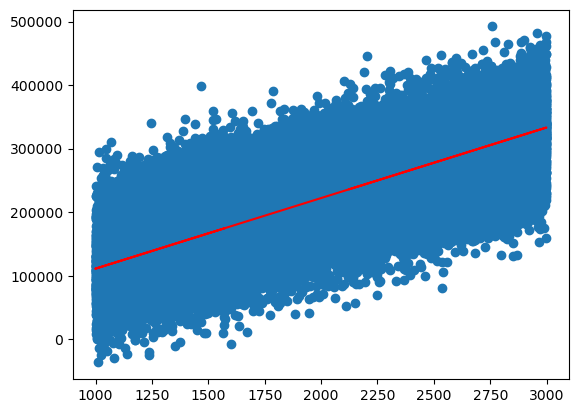

In [27]:
#regression lineaire simple(from scratch)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("housing_price_dataset.csv")

X = df["SquareFeet"].values
y = df["Price"].values

def regression_lineaire_simple(X, y, alpha=0.00000001, iterations=1000):
    a = 0.0
    b = 0.0
    m = len(y)

    for i in range(iterations):
        y_pred = a * X + b
        erreur = y_pred - y
        
        #Calculer les gradients
        
        da = (1/m) * np.sum(erreur * X)
        db = (1/m) * np.sum(erreur)
        
        #Mettre à jour les paramètres
        
        a -= alpha * da
        b -= alpha * db
        mse=(np.sum(erreur**2))/(2*m)
        if i==999:
            print(f"loss {mse}")
    return a, b

a, b = regression_lineaire_simple(X, y)

new_df = pd.DataFrame({"SquareFeet": [2000]})
y_pred = a * new_df["SquareFeet"].values + b

print("Prediction:", y_pred)
plt.scatter(X,y)
Y_pred = a * X + b
plt.plot(X,Y_pred,color='red')
plt.show()
#on a pas la meme valeur que celle de regression lineaire simple avec biblio car en a utiliser la methode d aproximation Gradient Descent 
#la regression lineaire simple avec biblio utulise la methode exacte

In [23]:
# regression lineaire multiple (from scratch)
import numpy as np
import pandas as pd

df = pd.read_csv("housing_price_dataset.csv")

def regression_lineaire_multivariee(X, y, alpha=0.01, iterations=1000):

    m = X.shape[0]  # nombre de lignes 
    
    # ajouter une colonne de 1 pour le biais (intercept)
    colonne_un = np.ones((m, 1))
    X_b = np.hstack((colonne_un, X))
    
    # initialiser les poids à 0 (y = w0 + w1*x1 + w2*x2 + ...)
    W = np.zeros((X_b.shape[1], 1))
    
    for i in range(iterations):
        
        # calcul des prédictions
        y_pred = X_b @ W
        
        # calcul de l'erreur 
        erreur = y_pred - y
        
        # calcul des gradients 
        gradients = (1/m) * (X_b.T @ erreur)
        
        # mise à jour des poids
        W = W - alpha * gradients

        mse=(np.sum(erreur**2))/(2*m)
        if i==999:
            print(f"loss {mse}")
        
    return W
X = df[["SquareFeet", "Bedrooms", "Bathrooms", "YearBuilt"]].values 
y = df["Price"].values.reshape(-1, 1)


theta = regression_lineaire_multivariee(X, y, alpha=0.00000001, iterations=50000)
new_df = pd.DataFrame({ "SquareFeet": [2000],
                         "Bedrooms": [3],
                         "Bathrooms": [2],
                         "YearBuilt": [2010] })

# Ajouter la colonne de 1 pour l'intercept 
new_Xb = np.hstack([np.ones((new_df.shape[0], 1)), new_df.values]) 

# Calcul des prédictions 
y_pred = new_Xb @ theta 
print("Prediction:", y_pred)
#on a pas la meme valeur que celle de regression lineaire simple avec biblio car en a utiliser la methode d aproximation Gradient Descent 
#la regression lineaire simple avec biblio utulise la methode exacte

loss 1276446291.4602728
Prediction: [[224503.09270407]]


In [24]:
# regression lineaire polynomiale (from scratch)
import numpy as np
import pandas as pd

df = pd.read_csv("housing_price_dataset.csv")

X = df["SquareFeet"].values
y = df["Price"].values

def regression_polynomiale(X, y, alpha=0.0000000000000001, iterations=100000):
    
    m = len(y)

    # créer les variables polynomiales (x et x²)
    X_poly = np.c_[np.ones(m), X, X**2]

    # initialiser les paramètres(degree 2)
    w0 = 0.0
    w1 = 0.0
    w2 = 0.0

    for i in range(iterations):

        # calcul des prédictions
        y_pred = w0 + w1 * X + w2 * (X**2)

        # calcul de l'erreur
        erreur = y_pred - y

        # calcul des gradients
        dw0 = (1/m) * np.sum(erreur)
        dw1 = (1/m) * np.sum(erreur * X)
        dw2 = (1/m) * np.sum(erreur * (X**2))

        # mise à jour des paramètres
        w0 -= alpha * dw0
        w1 -= alpha * dw1
        w2 -= alpha * dw2

        mse=(np.sum(erreur**2))/(2*m)
        if i==9999:
            print(f"loss {mse}")
            
    return w0, w1, w2

# training
w0, w1, w2 = regression_polynomiale(X, y)

# prédiction avec DataFrame
new_df = pd.DataFrame({"SquareFeet": [2000]})

x = new_df["SquareFeet"].values
y_pred = w0 + w1 * x + w2 * (x**2)

print("Prediction:", y_pred)

loss 2848694099.452186
Prediction: [182291.54791441]
